# IPL Player Statistics Analysis

This project analyzes IPL player statistics using Python.  
The analysis focuses on batting performance, strike rates, consistency, and player comparisons through exploratory data analysis and visualizations.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

In [6]:
from pathlib import Path

data_dir = Path.cwd()
if not (data_dir / "data" / "raw" / "matches.csv").exists():
	data_dir = data_dir.parent

matches = pd.read_csv(data_dir / "data" / "raw" / "matches.csv")
deliveries = pd.read_csv(data_dir / "data" / "raw" / "deliveries.csv")

In [7]:
print("Matches Dataset")
display(matches.head())

print("\nDeliveries Dataset")
display(deliveries.head())

Matches Dataset


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan



Deliveries Dataset


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:
print(matches.info())

print("\n")

print(deliveries.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [9]:
print("Missing Values in Matches Dataset")
print(matches.isnull().sum())

print("\nMissing Values in Deliveries Dataset")
print(deliveries.isnull().sum())

Missing Values in Matches Dataset
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Missing Values in Deliveries Dataset
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fie

In [10]:
matches = matches.drop_duplicates()
deliveries = deliveries.drop_duplicates()

matches.fillna("Unknown", inplace=True)
deliveries.fillna(0, inplace=True)

C:\Users\sanja\AppData\Local\Temp\ipykernel_14752\111321463.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  matches.fillna("Unknown", inplace=True)


In [11]:
batsman_runs = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)

top_batsmen = batsman_runs.head(10)

print(top_batsmen)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


# Exporting Visualizations

The following section saves analytical plots for documentation and GitHub presentation.

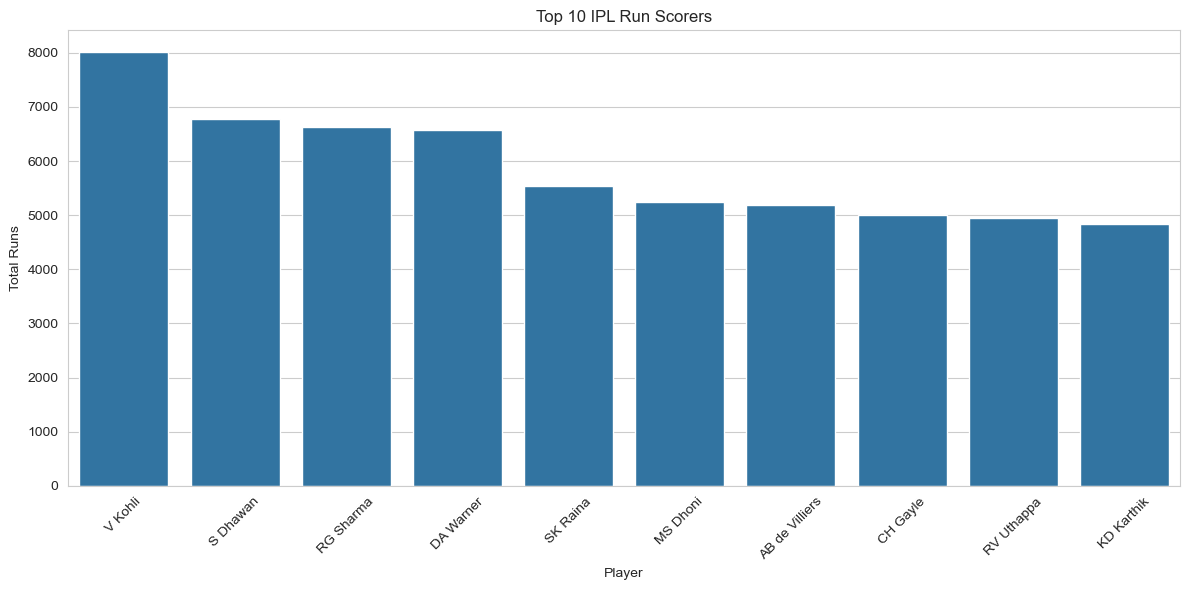

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_batsmen.index,
    y=top_batsmen.values
)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Total Runs")

plt.xticks(rotation=45)

plt.tight_layout()

output_path = Path("images/plots/top_run_scorers.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
balls_faced = deliveries.groupby("batter")["ball"].count()

strike_rate = (
    batsman_runs / balls_faced
) * 100

strike_rate = strike_rate.sort_values(ascending=False)

qualified_batsmen = strike_rate[balls_faced > 500]

top_strike_rate = qualified_batsmen.head(10)

print(top_strike_rate)

batter
AD Russell         164.224422
H Klaasen          161.990212
SP Narine          155.894309
N Pooran           154.768154
LS Livingstone     154.187192
GJ Maxwell         150.488599
RM Patidar         149.625468
Abhishek Sharma    148.864865
V Sehwag           148.827059
AB de Villiers     148.580442
dtype: float64


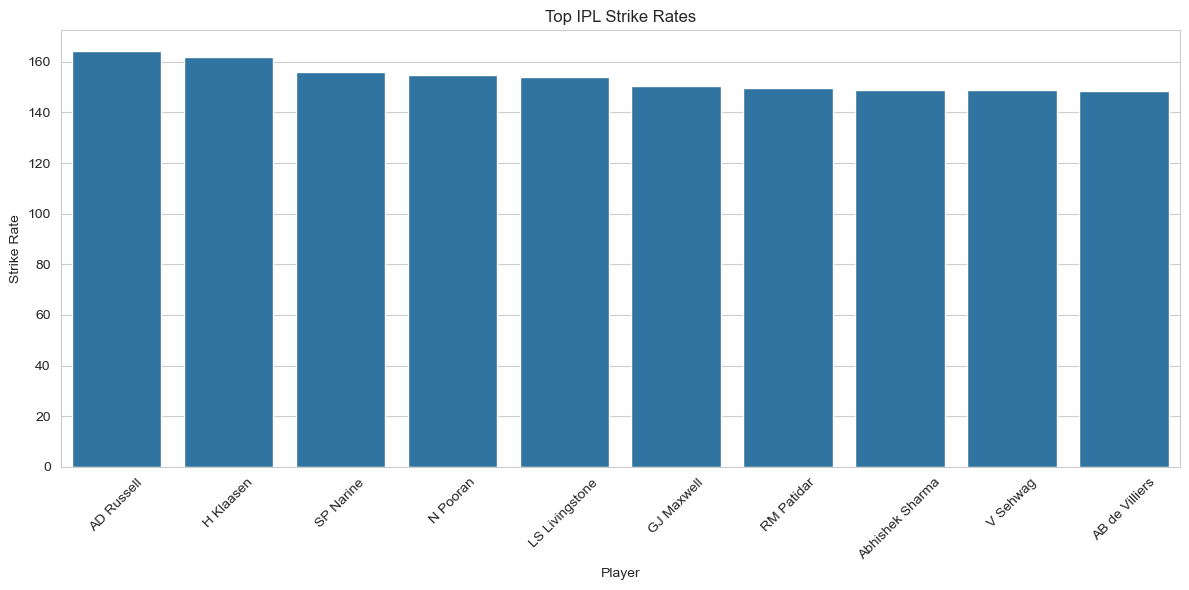

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_strike_rate.index,
    y=top_strike_rate.values
)

plt.title("Top IPL Strike Rates")
plt.xlabel("Player")
plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/plots/strike_rate_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
sixes = deliveries[deliveries["batsman_runs"] == 6]

most_sixes = (
    sixes.groupby("batter")["batsman_runs"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(most_sixes)

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64


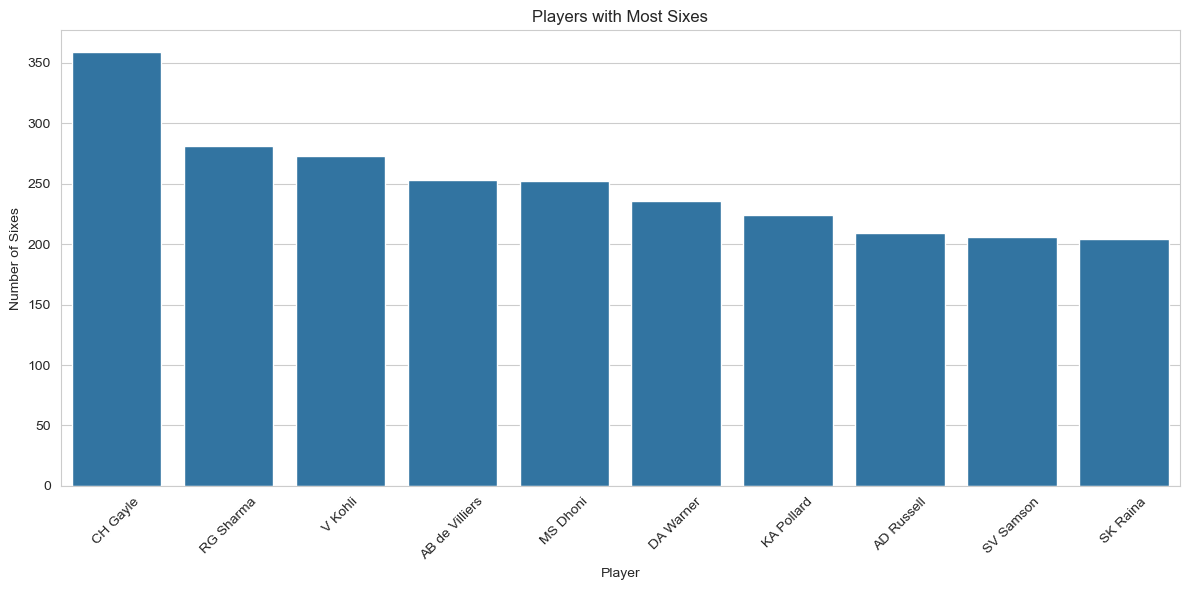

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=most_sixes.index,
    y=most_sixes.values
)

plt.title("Players with Most Sixes")
plt.xlabel("Player")
plt.ylabel("Number of Sixes")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/plots/most_sixes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
toss_decision = matches["toss_decision"].value_counts()

print(toss_decision)

toss_decision
field    704
bat      391
Name: count, dtype: int64


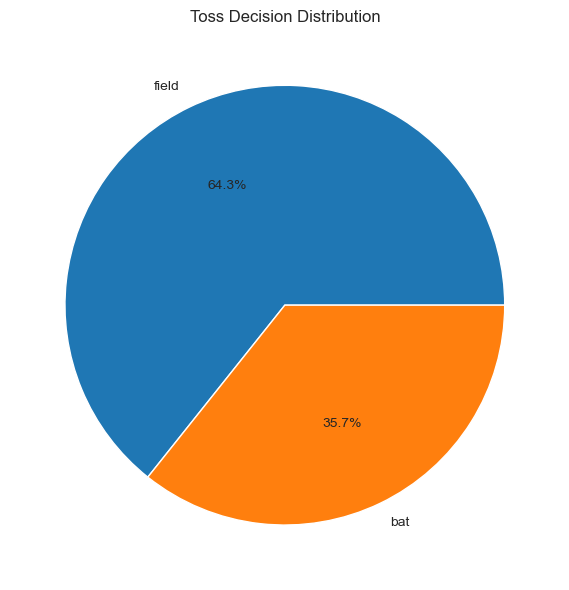

In [29]:
plt.figure(figsize=(6,6))

plt.pie(
    toss_decision.values,
    labels=toss_decision.index,
    autopct="%1.1f%%"
)

plt.title("Toss Decision Distribution")

plt.tight_layout()

plt.savefig(
    "images/plots/toss_decision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
top_winners = matches["winner"].value_counts().head(10)

print(top_winners)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


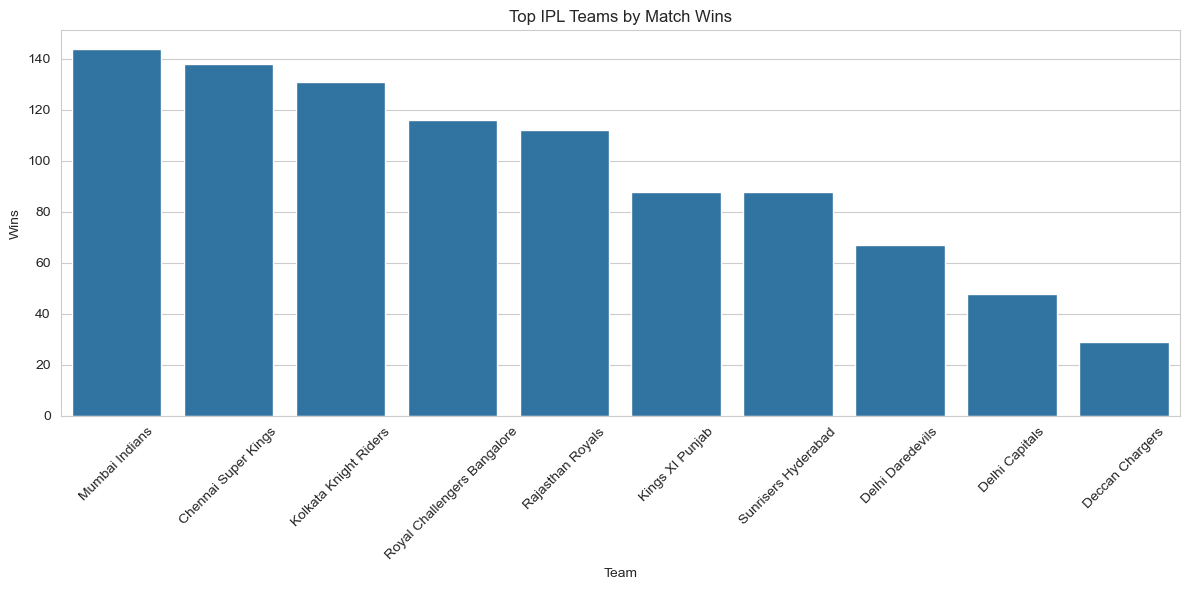

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_winners.index,
    y=top_winners.values
)

plt.title("Top IPL Teams by Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/plots/top_winning_teams.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Key Insights and Observations

- Certain batsmen consistently dominate IPL run-scoring charts.
- Aggressive batters maintain exceptionally high strike rates.
- Power hitters contribute significantly through boundary scoring.
- Toss decisions indicate strategic preference toward chasing.
- Some IPL franchises have maintained long-term dominance in overall wins.

# Final Conclusion

This project successfully analyzed IPL player and team statistics using Python data analytics libraries.

The project demonstrated:
- Data preprocessing
- Statistical analysis
- Sports analytics
- Data visualization techniques

The analysis provided meaningful insights into batting performance, strike rate efficiency, six-hitting trends, toss strategies, and team dominance within the IPL.